# Setting

In [30]:
import os
import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
from scipy import stats
from collections import defaultdict

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
import seaborn as sns

from statsmodels.stats.multitest import multipletests
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

import warnings
warnings.filterwarnings('ignore')

In [31]:
# Paths
BASE_DIR = Path('../')
NETWORK_DIR = BASE_DIR / 'result' / 'networks'
OUTPUT_DIR = BASE_DIR / 'result'
FIGURES_DIR = OUTPUT_DIR / 'figures'
TABLES_DIR = OUTPUT_DIR / 'tables'
DATA_FILE = BASE_DIR / 'db' / 'total_only_org.csv'
excel_file = TABLES_DIR / 'Tables.xlsx'

# Create directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [32]:
# Set style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

In [33]:
M_GROUPS = [
    ('남성', '청년층(19-39세)', 'MetS(+)'),
    ('남성', '중년층(40-59세)', 'MetS(+)'),
    ('남성', '장년층(60-74세)', 'MetS(+)'),
    ('남성', '중년층(40-59세)', 'MetS(-)'),
    ('남성', '청년층(19-39세)', 'MetS(-)'),
    ('남성', '장년층(60-74세)', 'MetS(-)'),
]
F_GROUPS = [
    ('여성', '청년층(19-39세)', 'MetS(+)'),
    ('여성', '중년층(40-59세)', 'MetS(+)'),
    ('여성', '장년층(60-74세)', 'MetS(+)'),
    ('여성', '청년층(19-39세)', 'MetS(-)'),
    ('여성', '중년층(40-59세)', 'MetS(-)'),
    ('여성', '장년층(60-74세)', 'MetS(-)'),
]

M_GROUP_LABELS = [
    'Male_Young_MetS(+)',
    'Male_Middle_MetS(+)',
    'Male_Older_MetS(+)',
    'Male_Young_MetS(-)',
    'Male_Middle_MetS(-)',
    'Male_Older_MetS(-)',
]
F_GROUP_LABELS = [
    'Female_Young_MetS(+)',
    'Female_Middle_MetS(+)',
    'Female_Older_MetS(+)',
    'Female_Young_MetS(-)',
    'Female_Middle_MetS(-)',
    'Female_Older_MetS(-)',
]

GROUPS = M_GROUPS + F_GROUPS
GROUP_LABELS = M_GROUP_LABELS + F_GROUP_LABELS

GROUP_MAPPING = {
    'Male_Young': ('남성', '청년층(19-39세)'),
    'Male_Middle': ('남성', '중년층(40-59세)'),
    'Male_Older': ('남성', '장년층(60-74세)'),
    'Female_Young': ('여성', '청년층(19-39세)'),
    'Female_Middle': ('여성', '중년층(40-59세)'),
    'Female_Older': ('여성', '장년층(60-74세)'),
}

SEX_DISPLAY = {'M': '남성', 'F': '여성'}
SEX_REVERSE = {'남성': 'M', '여성': 'F'}

FOOD_ABBREV = {
'Grain Products': 'GRAIN',
    'Protein Foods': 'PROT\nEIN',
    'Vegetables': 'VEG',
    'Dairy Products': 'DAIRY',
    'Fruits': 'FRUIT',
    'Fried Foods': 'FRIED',
    'High Fat Meat': 'HF\nMEAT',
    'Processed Foods': 'PROC\nESSED',
    'Sugar-Sweetened Beverages': 'SSB',
    'Additional Salt Use': 'ADD\nSALT',
    'Salty Food Consumption': 'SALTY',
    'Sweet Food Consumption': 'SWEET'}

HEALTH_INDICATORS = ['BMI(kg/m2)', 'Waist circumference (cm)', 'Systolic blood pressure (mmHg)',
                     'Diastolic Blood Pressure (mmHg)', 'Fasting glucose (mg/dL)',
                     'Triglycerides (mg/dL)', 'HDL-C (mg/dL)']

def load_raw_data():
    df = pd.read_csv(DATA_FILE)
    
    def categorize_age(age):
        if age < 40:
            return '청년층(19-39세)'
        elif age < 60:
            return '중년층(40-59세)'
        else:
            return '장년층(60-74세)'
    
    df['Age_Group'] = df['Age'].apply(categorize_age)
    df['MetS_Status'] = df['MetS'].apply(lambda x: 'MetS(+)' if x == 1 else 'MetS(-)')
    return df

def load_network(sex, age_group, mets_status):
    filename = f"ggm_network_{sex}_{age_group}_{mets_status}.gexf"
    filepath = NETWORK_DIR / filename
    if filepath.exists():
        return nx.read_gexf(str(filepath))
    return None

def load_statistics():
    stats_file = NETWORK_DIR / 'ggm_network_summary.csv'
    if stats_file.exists():
        return pd.read_csv(stats_file)
    return None

def load_all_community_data():
    summary_df = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')
    
    all_data = []
    for _, row in summary_df.iterrows():
        group = row['Group']
        
        community_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
        if community_file.exists():
            comm_df = pd.read_csv(community_file)
            comm_df['Group'] = group
            all_data.append(comm_df)
    
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

def load_partial_corr_matrix(sex, age_group, mets_status):
    filename = f"ggm_network_{sex}_{age_group}_{mets_status}_partial_corr.csv"
    filepath = NETWORK_DIR / filename
    
    if filepath.exists():
        return pd.read_csv(filepath, index_col=0)
    return None

# 3.1. Study Population Characteristics

## TABLE S1: Diet Question

In [34]:
data = {
    "Variables": [
        "Grain Products", "", "",
        "Protein Foods", "", "", "",
        "Vegetables", "", "", "",
        "Dairy Products", "", "", "",
        "Fruits", "", "",
        "Fried Foods", "", "", "",
        "High Fat Meat", "", "", "",
        "Processed Foods", "", "", "",
        "Sugar-Sweetened Beverages", "", "", "",
        "Additional Salt Use", "", "",
        "Salty Food Consumption", "", "",
        "Sweet Food Consumption", "", ""
    ],
    "Definition": [
        "How often do you eat grains?", "", "",
        "How often do you eat one of dishes like meat, fish, tofu, or eggs?", "", "", "",
        "How often do you eat vegetables?", "", "", "",
        "How often do you drink milk and dairy products?", "", "", "",
        "How often do you eat fruits?", "", "",
        "How often do you eat fried food?", "", "", "",
        "How often do you eat fat rich meat?", "", "", "",
        "How often do you eat instant and processed food?", "", "", "",
        "How often do you drink juice, soft, or instant drinks?", "", "", "",
        "Do you usually add more salt or soy sauce to your food?", "", "",
        "Do you usually eat salty food like fermented fish, pickled vegetable or soup?", "", "",
        "Do you usually eat sweets?", "", ""
    ],
    "Value": [
        3, 2, 1,
        4, 3, 2, 1,
        4, 3, 2, 1,
        4, 3, 2, 1,
        3, 2, 1,
        4, 3, 2, 1,
        4, 3, 2, 1,
        4, 3, 2, 1,
        4, 3, 2, 1,
        3, 2, 1,
        3, 2, 1,
        3, 2, 1
    ],
    "Feature": [
        "3 times/day", "1–2 time(s)/day", "Less than 6 times/week",
        "More than 2 times/day", "Once a day", "3–6 times/week", "Less than 2 times/ week or hardly",
        "More than 2 times/day", "Once a day", "3–6 times/week", "Less than 2 times/ week or hardly",
        "More than 2 times/day", "Once a day", "3–6 times/week", "Less than 2 times/ week or hardly",
        "Everyday", "3–6 times/week", "Less than 2 times/ week or hardly",
        "More than 2 times/day", "Once a day", "3–6 times/week", "Less than 2 times/ week or hardly",
        "More than 2 times/day", "Once a day", "3–6 times/week", "Less than 2 times/ week or hardly",
        "More than 2 times/day", "Once a day", "3–6 times/week", "Less than 2 times/ week or hardly",
        "More than 2 glasses/day", "1 glass/day", "3–6 glasses/week", "Less than 1–2 glass(es)/week or hardly",
        "Often", "Sometimes", "Never",
        "YES", "Sometimes", "NO",
        "Often (more than 3/week)", "Sometimes (less than 2/week)", "Never"
    ]
}

df = pd.DataFrame(data)

df['Variables'] = df['Variables'].replace('', pd.NA).ffill()
df['Definition'] = df['Definition'].replace('', pd.NA).ffill()

df.to_excel(excel_file, index=False, sheet_name="Table S1. Dietary Questionnaire")

## TABLE S2: Population Characteristics by MetS Status and Subgroups

In [35]:
import generate_demographic_table

generate_demographic_table.main(excel_filename=str(excel_file))

Demographic Table Generation - 12 Groups Analysis

[1/4] Loading and preprocessing data...
    Total subjects: 23040
    Men: 12294
    Women: 10746

[2/4] Generating summary statistics for 12 groups...
    Summary statistics generation complete!

[3/4] Calculating p-values for 12 groups...
    Variables tested: 46
    Significant (p<0.05): 46

[4/4] Generating Excel file...
    Loading existing file: ../result/tables/Tables.xlsx
    Sheet 'Table S2. Baseline Characteristics' created successfully!

Excel file saved successfully: ../result/tables/Tables.xlsx
Sheets created: ['Table S1. Dietary Questionnaire', 'Table S2. Baseline Characteristics']



# 3.2. Food Network Construction  and Hub Identification

## FIGURE 1: Dietary Network

  Centrality range: 0.000 - 0.455


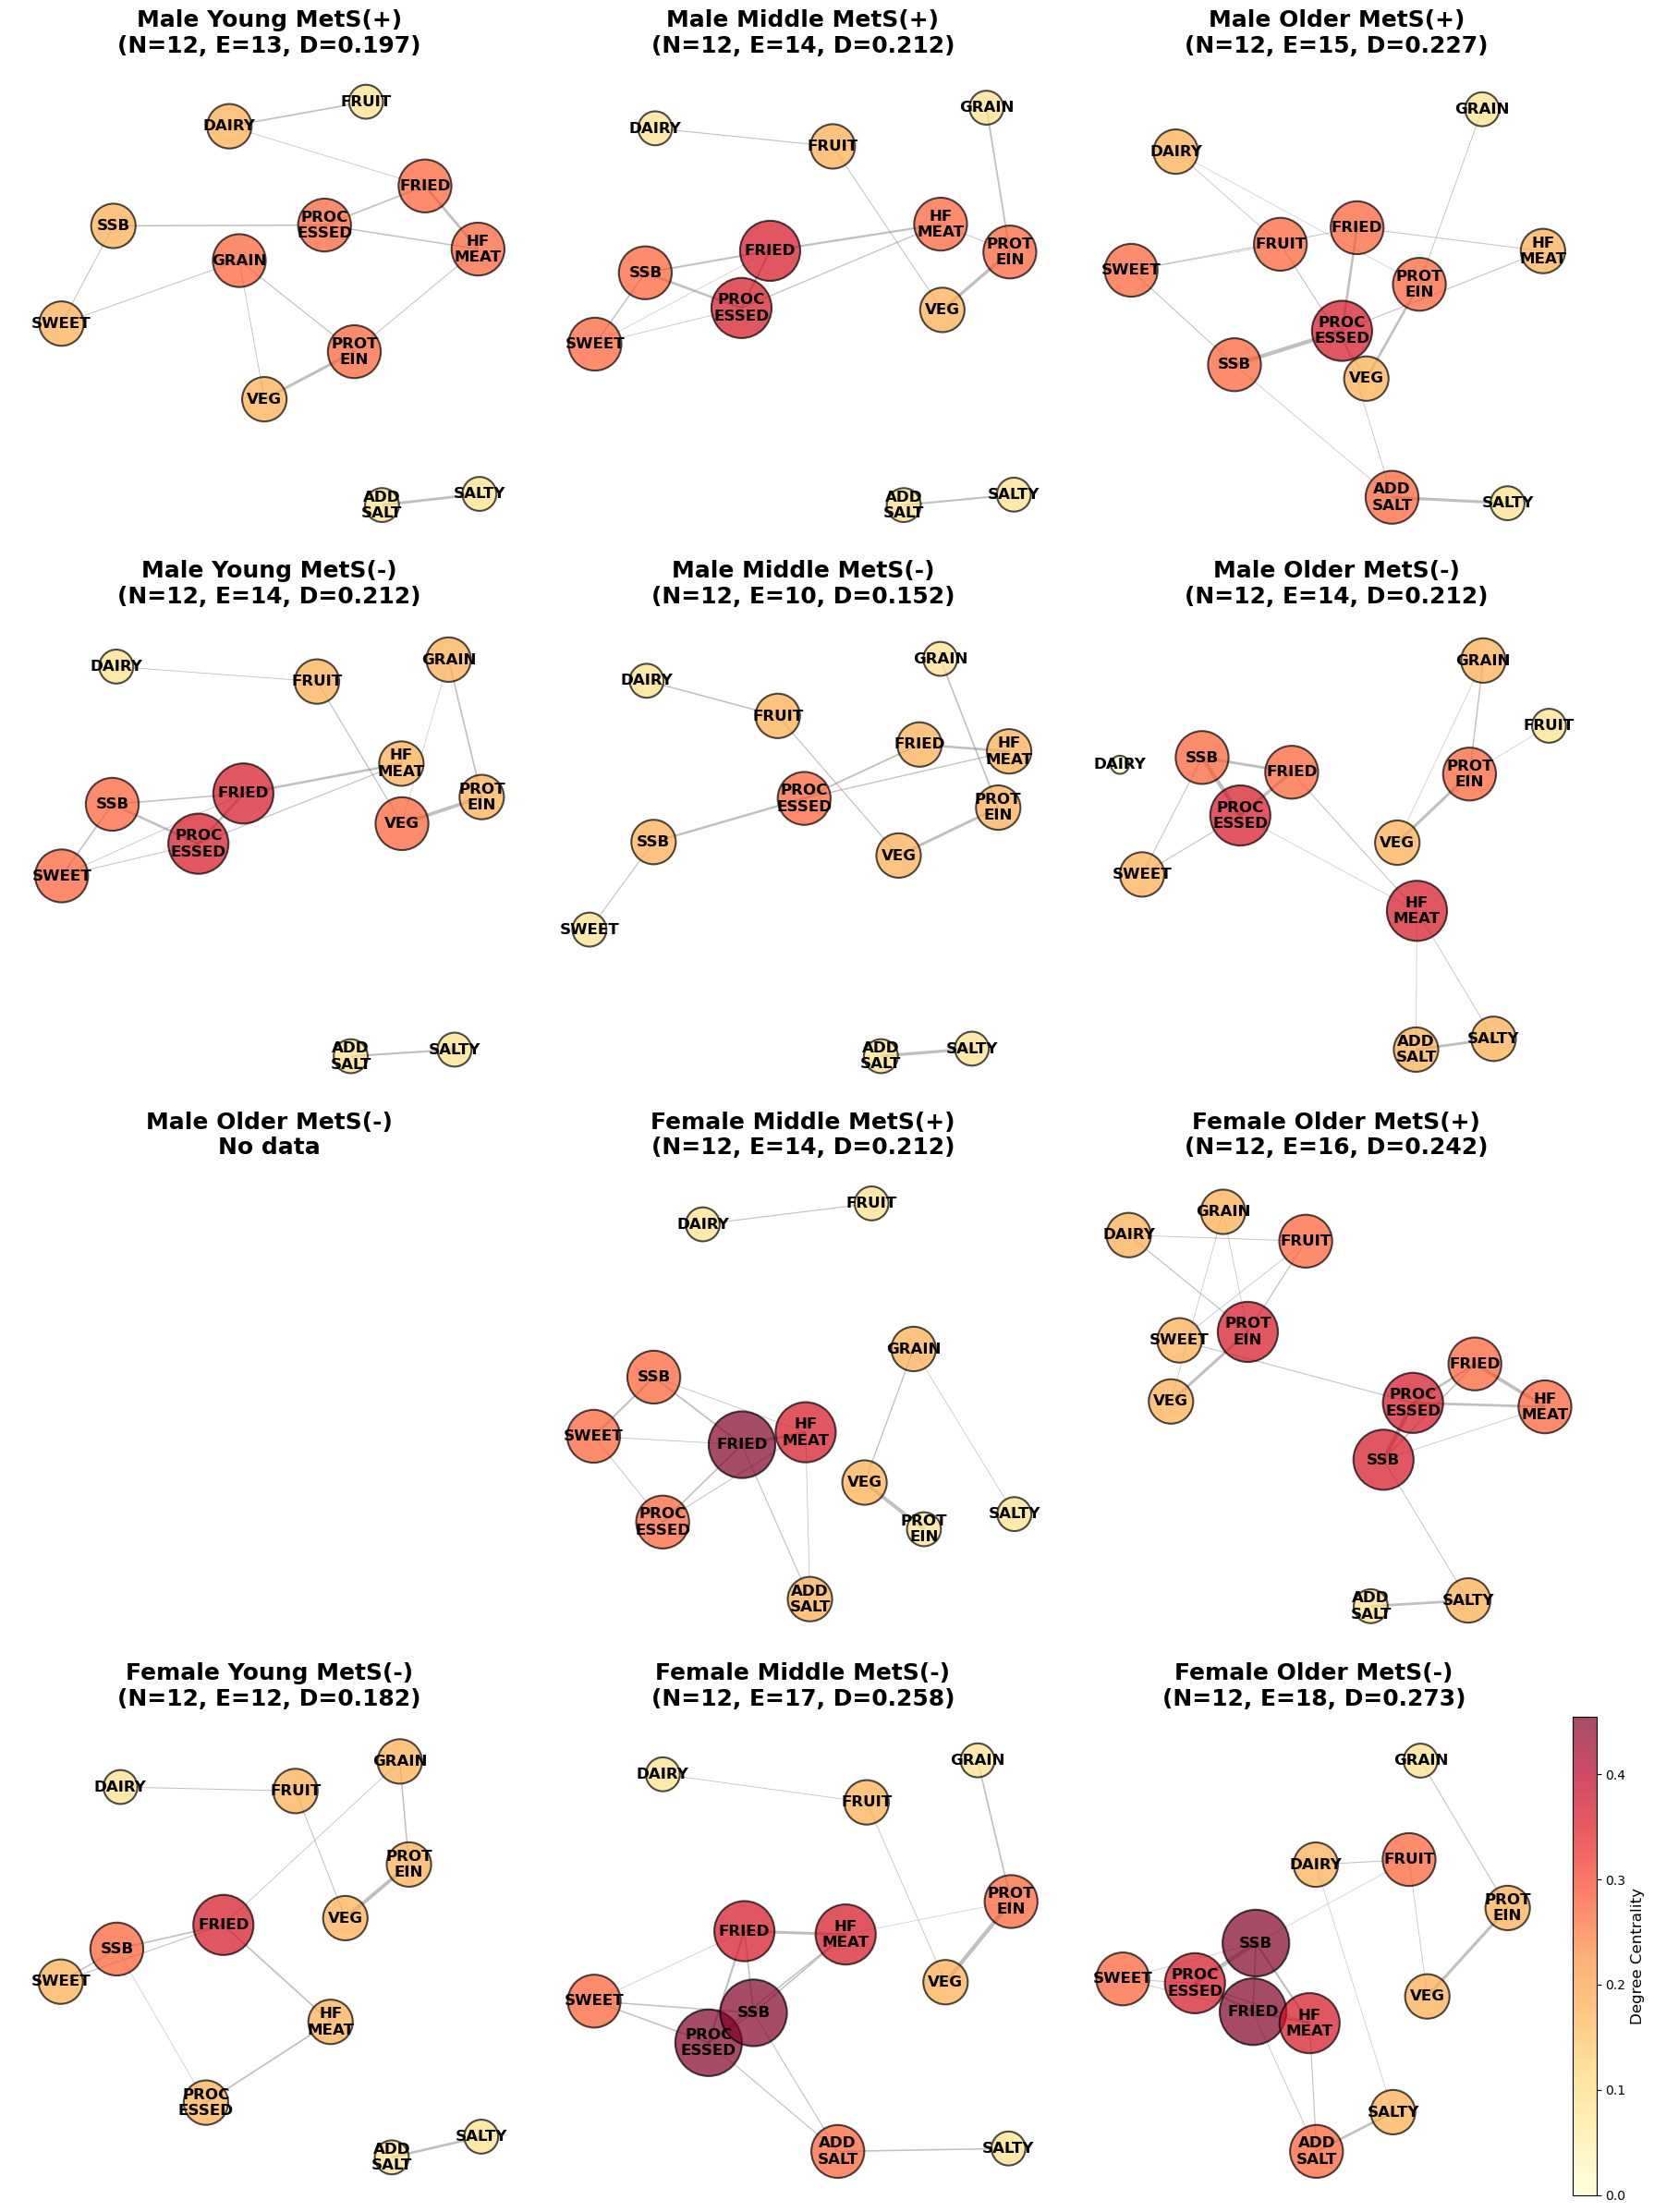

In [36]:
fig, axes = plt.subplots(4, 3, figsize=(18, 24))
axes = axes.flatten()

last_nodes = None
all_centralities = []

# Collect all centrality values
for sex, age_group, mets_status in GROUPS:
    G = load_network(sex, age_group, mets_status)
    if G is not None and G.number_of_nodes() > 0:
        centrality = nx.degree_centrality(G)
        all_centralities.extend(centrality.values())

# Calculate vmin/vmax from actual data
vmin = min(all_centralities) if all_centralities else 0
vmax = max(all_centralities) if all_centralities else 1
print(f"  Centrality range: {vmin:.3f} - {vmax:.3f}")

# Create network images
for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    ax = axes[idx]
    G = load_network(sex, age_group, mets_status)
    
    if G is None or G.number_of_nodes() == 0:
        ax.set_title(
            f"{title}\nNo data",
            fontsize=18,
            fontweight='bold'
        )
        ax.axis('off')
        continue
    
    pos = nx.spring_layout(G, k=0.5, iterations=50, seed=42) # Force-directed layout
    
    # Node sizes based on degree
    degrees = dict(G.degree())
    node_sizes = [degrees[node] * 500 + 200 for node in G.nodes()]
    
    # Node colors based on degree centrality
    centrality = nx.degree_centrality(G)
    node_colors = [centrality[node] for node in G.nodes()]
    
    # Draw edges with varying widths based on partial correlation
    for u, v, data in G.edges(data=True):
        weight = data.get('weight', 1.0)
        nx.draw_networkx_edges(
            G, pos, [(u, v)], 
            ax=ax, 
            alpha=0.5, 
            width=weight * 8,
            edge_color='gray'
        )
    
    # Draw nodes with adjusted vmin/vmax
    nodes = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        cmap='YlOrRd',
        vmin=vmin, vmax=vmax,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.5
    )
    last_nodes = nodes
    
    # Draw labels with automatic line breaks
    labels_dict = {node: FOOD_ABBREV.get(node, node[:4]) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels_dict, ax=ax, font_size=12, font_weight='bold')
    
    ax.margins(0.1)

    # Title
    title = GROUP_LABELS[idx].replace('_', ' ')
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    density = nx.density(G)
    
    ax.set_title(
        f"{title}\n(N={n_nodes}, E={n_edges}, D={density:.3f})",
        fontsize=18,
        fontweight='bold'
    )
    ax.axis('off')

# Hide unused subplots
for idx in range(len(GROUPS), len(axes)):
    axes[idx].axis('off')

# Add colorbar
if last_nodes is not None:
    cbar = plt.colorbar(last_nodes, ax=axes[-1], fraction=0.046, pad=0.04)
    cbar.set_label('Degree Centrality', fontsize=12)

plt.tight_layout()
output_file = FIGURES_DIR / 'Figure_1_Network_Visualizations_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='none', transparent=True)
#plt.close()

## TABLE S3: Top Hub Foods by Group

In [37]:
stats_df = load_statistics()
if stats_df is None:
    raise FileNotFoundError("Network statistics file not found!")

hub_data = []

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    G = load_network(sex, age_group, mets_status)
    
    if G is None:
        continue
        
    group_label = GROUP_LABELS[idx]
    
    stats_row = stats_df[
        (stats_df['Sex'] == sex) & 
        (stats_df['Age_Group'] == age_group) & 
        (stats_df['MetS_Status'] == mets_status)
    ]
    
    if len(stats_row) == 0:
        continue
    
    stats_row = stats_row.iloc[0]
    
    # Calculate centralities
    degree_cent = nx.degree_centrality(G)
    
    # Get top 5 hub foods by degree centrality
    top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:5]
    
    row_data = {
        'Group': group_label,
        'N_Samples': int(stats_row['N_Samples']),
        'N_Nodes': G.number_of_nodes(),
        'N_Edges': G.number_of_edges(),
        'Density': f"{nx.density(G):.3f}",
    }
    
    # Add top 5 hubs
    for i, (food, centrality) in enumerate(top_hubs, 1):
        row_data[f'Hub_{i}'] = food
        row_data[f'Hub_{i}_Centrality'] = f"{centrality:.3f}"
    
    hub_data.append(row_data)

df_hubs = pd.DataFrame(hub_data)

if os.path.exists(excel_file):
    with pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        df_hubs.to_excel(writer, sheet_name='Table S3. Top Hub Foods', index=False)
else:
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        df_hubs.to_excel(writer, sheet_name='Table S3. Top Hub Foods', index=False)

## FIGURE S1: Hub Food Centrality Comparison

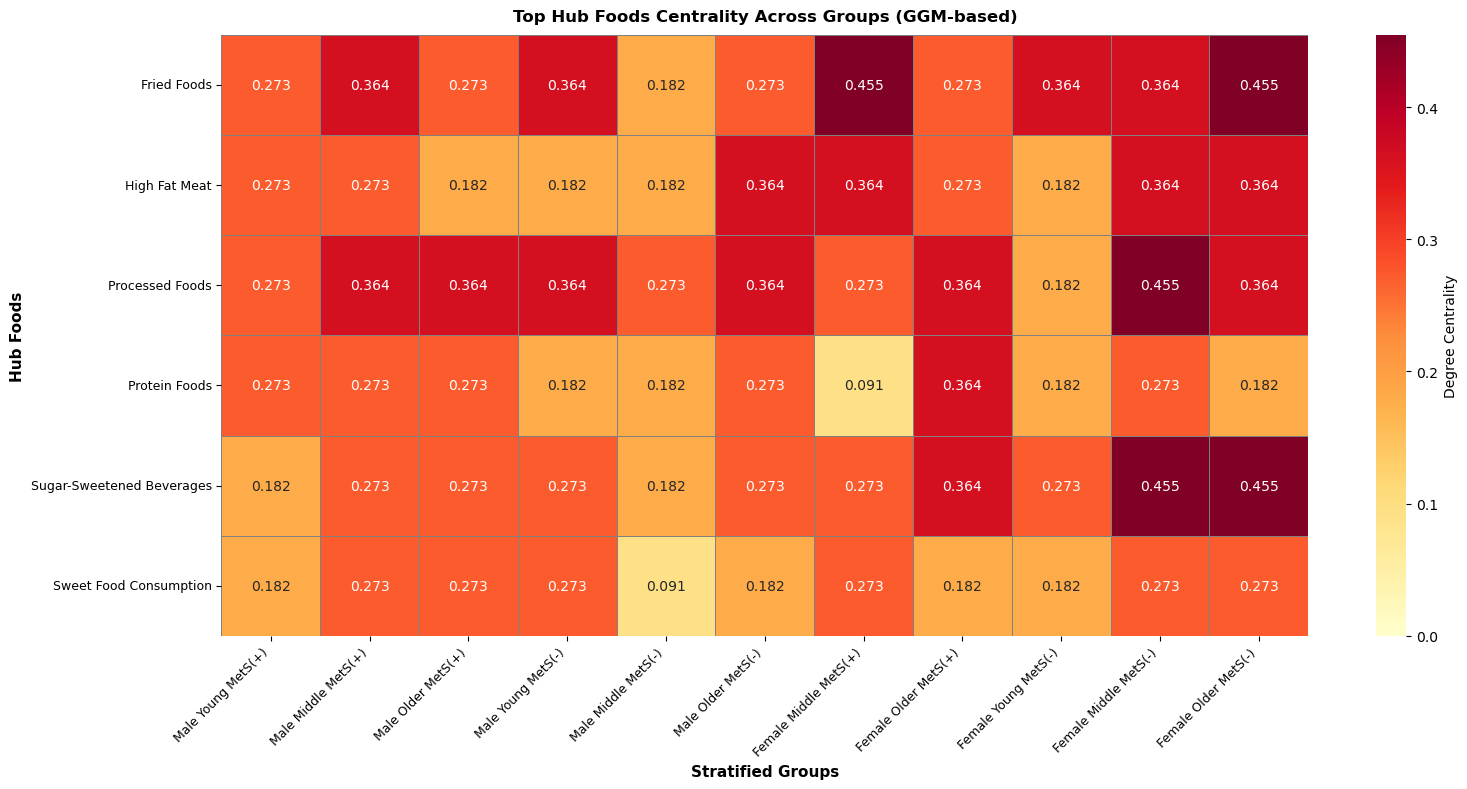

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

data = []
all_foods = set()

# 데이터 수집 루프
for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    G = load_network(sex, age_group, mets_status)
    if G is None:
        continue
    
    centrality = nx.degree_centrality(G)
    for food, cent_value in centrality.items():
        all_foods.add(food)
        data.append({
            'Group': GROUP_LABELS[idx].replace('_', ' '),
            'Food': food,
            'Centrality': cent_value
        })

df = pd.DataFrame(data)

# Top hub foods 선택
food_avg_centrality = df.groupby('Food')['Centrality'].mean().sort_values(ascending=False)
top_hub_foods = food_avg_centrality.head(6).index.tolist()

# 피벗 테이블 생성 (Food x Group)
df_top_hubs = df[df['Food'].isin(top_hub_foods)]
heatmap_data = df_top_hubs.pivot_table(
    index='Food', 
    columns='Group', 
    values='Centrality', 
    fill_value=0
)

# 그룹 순서 맞추기
all_group_labels_clean = [g.replace('_', ' ') for g in GROUP_LABELS]
valid_group_labels = [label for label in all_group_labels_clean if label in heatmap_data.columns]

heatmap_data = heatmap_data[valid_group_labels]

# 히트맵 그리기
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

sns.heatmap(
    heatmap_data, 
    annot=True,  # 값 표시
    fmt='.3f',  # 소수점 3자리
    cmap='YlOrRd',  # 색상 맵
    cbar_kws={'label': 'Degree Centrality'},
    linewidths=0.5,  # 셀 구분선
    linecolor='gray',
    ax=ax,
    vmin=0,
    vmax=heatmap_data.values.max()
)

ax.set_xlabel('Stratified Groups', fontsize=11, fontweight='bold')
ax.set_ylabel('Hub Foods', fontsize=11, fontweight='bold')
ax.set_title('Top Hub Foods Centrality Across Groups (GGM-based)', fontsize=12, fontweight='bold', pad=10)

# X축 라벨 회전
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
output_file = FIGURES_DIR / 'Figure_S1_Hub_Centrality_Comparison_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')
# plt.show()

## TABLE S4: Network Edge List

In [39]:
all_edges = []

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    G = load_network(sex, age_group, mets_status)
    
    if G is None or G.number_of_edges() == 0:
        continue
    
    group_english = GROUP_LABELS[idx]
    
    for u, v, data in G.edges(data=True):
        weight = data.get('weight', 0)
        partial_corr = data.get('partial_corr', weight)
        
        all_edges.append({
            'Group': group_english,
            'Node 1': u,
            'Node 2': v,
            'Partial Correlation': f"{partial_corr:.4f}",
            'Absolute Weight': f"{weight:.4f}"
        })

df_edges = pd.DataFrame(all_edges)

if os.path.exists(excel_file):
    with pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        df_edges.to_excel(writer, sheet_name='Table S4. Network Edges', index=False)
else:
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        df_edges.to_excel(writer, sheet_name='Table S4. Network Edges', index=False)

## TABLE S5: Community analysis

In [40]:
def categorize_foods(food_list):
    healthy = []
    processed = []
    salt_related = []
    
    for food in food_list:
        if food in ['Grain Products', 'Protein Foods', 'Vegetables', 'Dairy Products', 'Fruits']:
            healthy.append(food)
        elif food in ['Fried Foods', 'High Fat Meat', 'Processed Foods', 
                      'Sugar-Sweetened Beverages', 'Sweet Food Consumption']:
            processed.append(food)
        else:
            salt_related.append(food)
    
    return healthy, processed, salt_related

def interpret_community(foods):
    healthy, processed, salt_related = categorize_foods(foods)
    
    if len(healthy) >= len(processed) and len(healthy) >= len(salt_related):
        if len(healthy) >= 4:
            return "Traditional Korean Diet Pattern"
        else:
            return "Mixed Healthy Pattern"
    elif len(processed) > len(healthy) and len(processed) >= len(salt_related):
        if len(processed) >= 4:
            return "Western/Processed Food Pattern"
        else:
            return "Mixed Processed Pattern"
    elif len(salt_related) >= 2:
        return "High Sodium Pattern"
    else:
        return "Mixed Pattern"

summary_df = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')

all_rows = []

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    group = f"{sex}_{age_group}_{mets_status}"
    
    # Load community file
    comm_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
    if not comm_file.exists():
        print(f"Warning: Community file not found: {comm_file}")
        continue
    
    comm_df = pd.read_csv(comm_file)
    
    # Get modularity and n_communities
    modularity = summary_df[summary_df['Group'] == group]['Modularity'].values[0]
    n_communities = len(comm_df)
    group_english = GROUP_LABELS[idx]
    
    # Process each community
    for _, row in comm_df.iterrows():
        comm_id = row['community_id']
        size = row['size']
        nodes = row['nodes'].split('; ')
        internal_edges = row['internal_edges']
        internal_density = row['internal_density']
        
        # Categorize foods
        healthy, processed, salt_related = categorize_foods(nodes)
        interpretation = interpret_community(nodes)
        
        # Format food lists
        healthy_str = ', '.join(healthy) if healthy else '-'
        processed_str = ', '.join(processed) if processed else '-'
        salt_str = ', '.join(salt_related) if salt_related else '-'
        
        all_rows.append({
            'Group': group_english,
            'Total Communities': n_communities,
            'Modularity': f"{modularity:.3f}",
            'Community ID': comm_id,
            'Size': size,
            'Internal Edges': internal_edges,
            'Internal Density': f"{internal_density:.3f}",
            'Healthy Foods': healthy_str,
            'Processed/Unhealthy Foods': processed_str,
            'Salt-related Foods': salt_str,
            'Dietary Pattern': interpretation
        })

# Create DataFrame
table_df = pd.DataFrame(all_rows)

if os.path.exists(excel_file):
    with pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        table_df.to_excel(writer, sheet_name='Table S5. Community Analysis', index=False)
else:
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        table_df.to_excel(writer, sheet_name='Table S5. Community Analysis', index=False)

## FIGURE S2: Community Structure Analysis

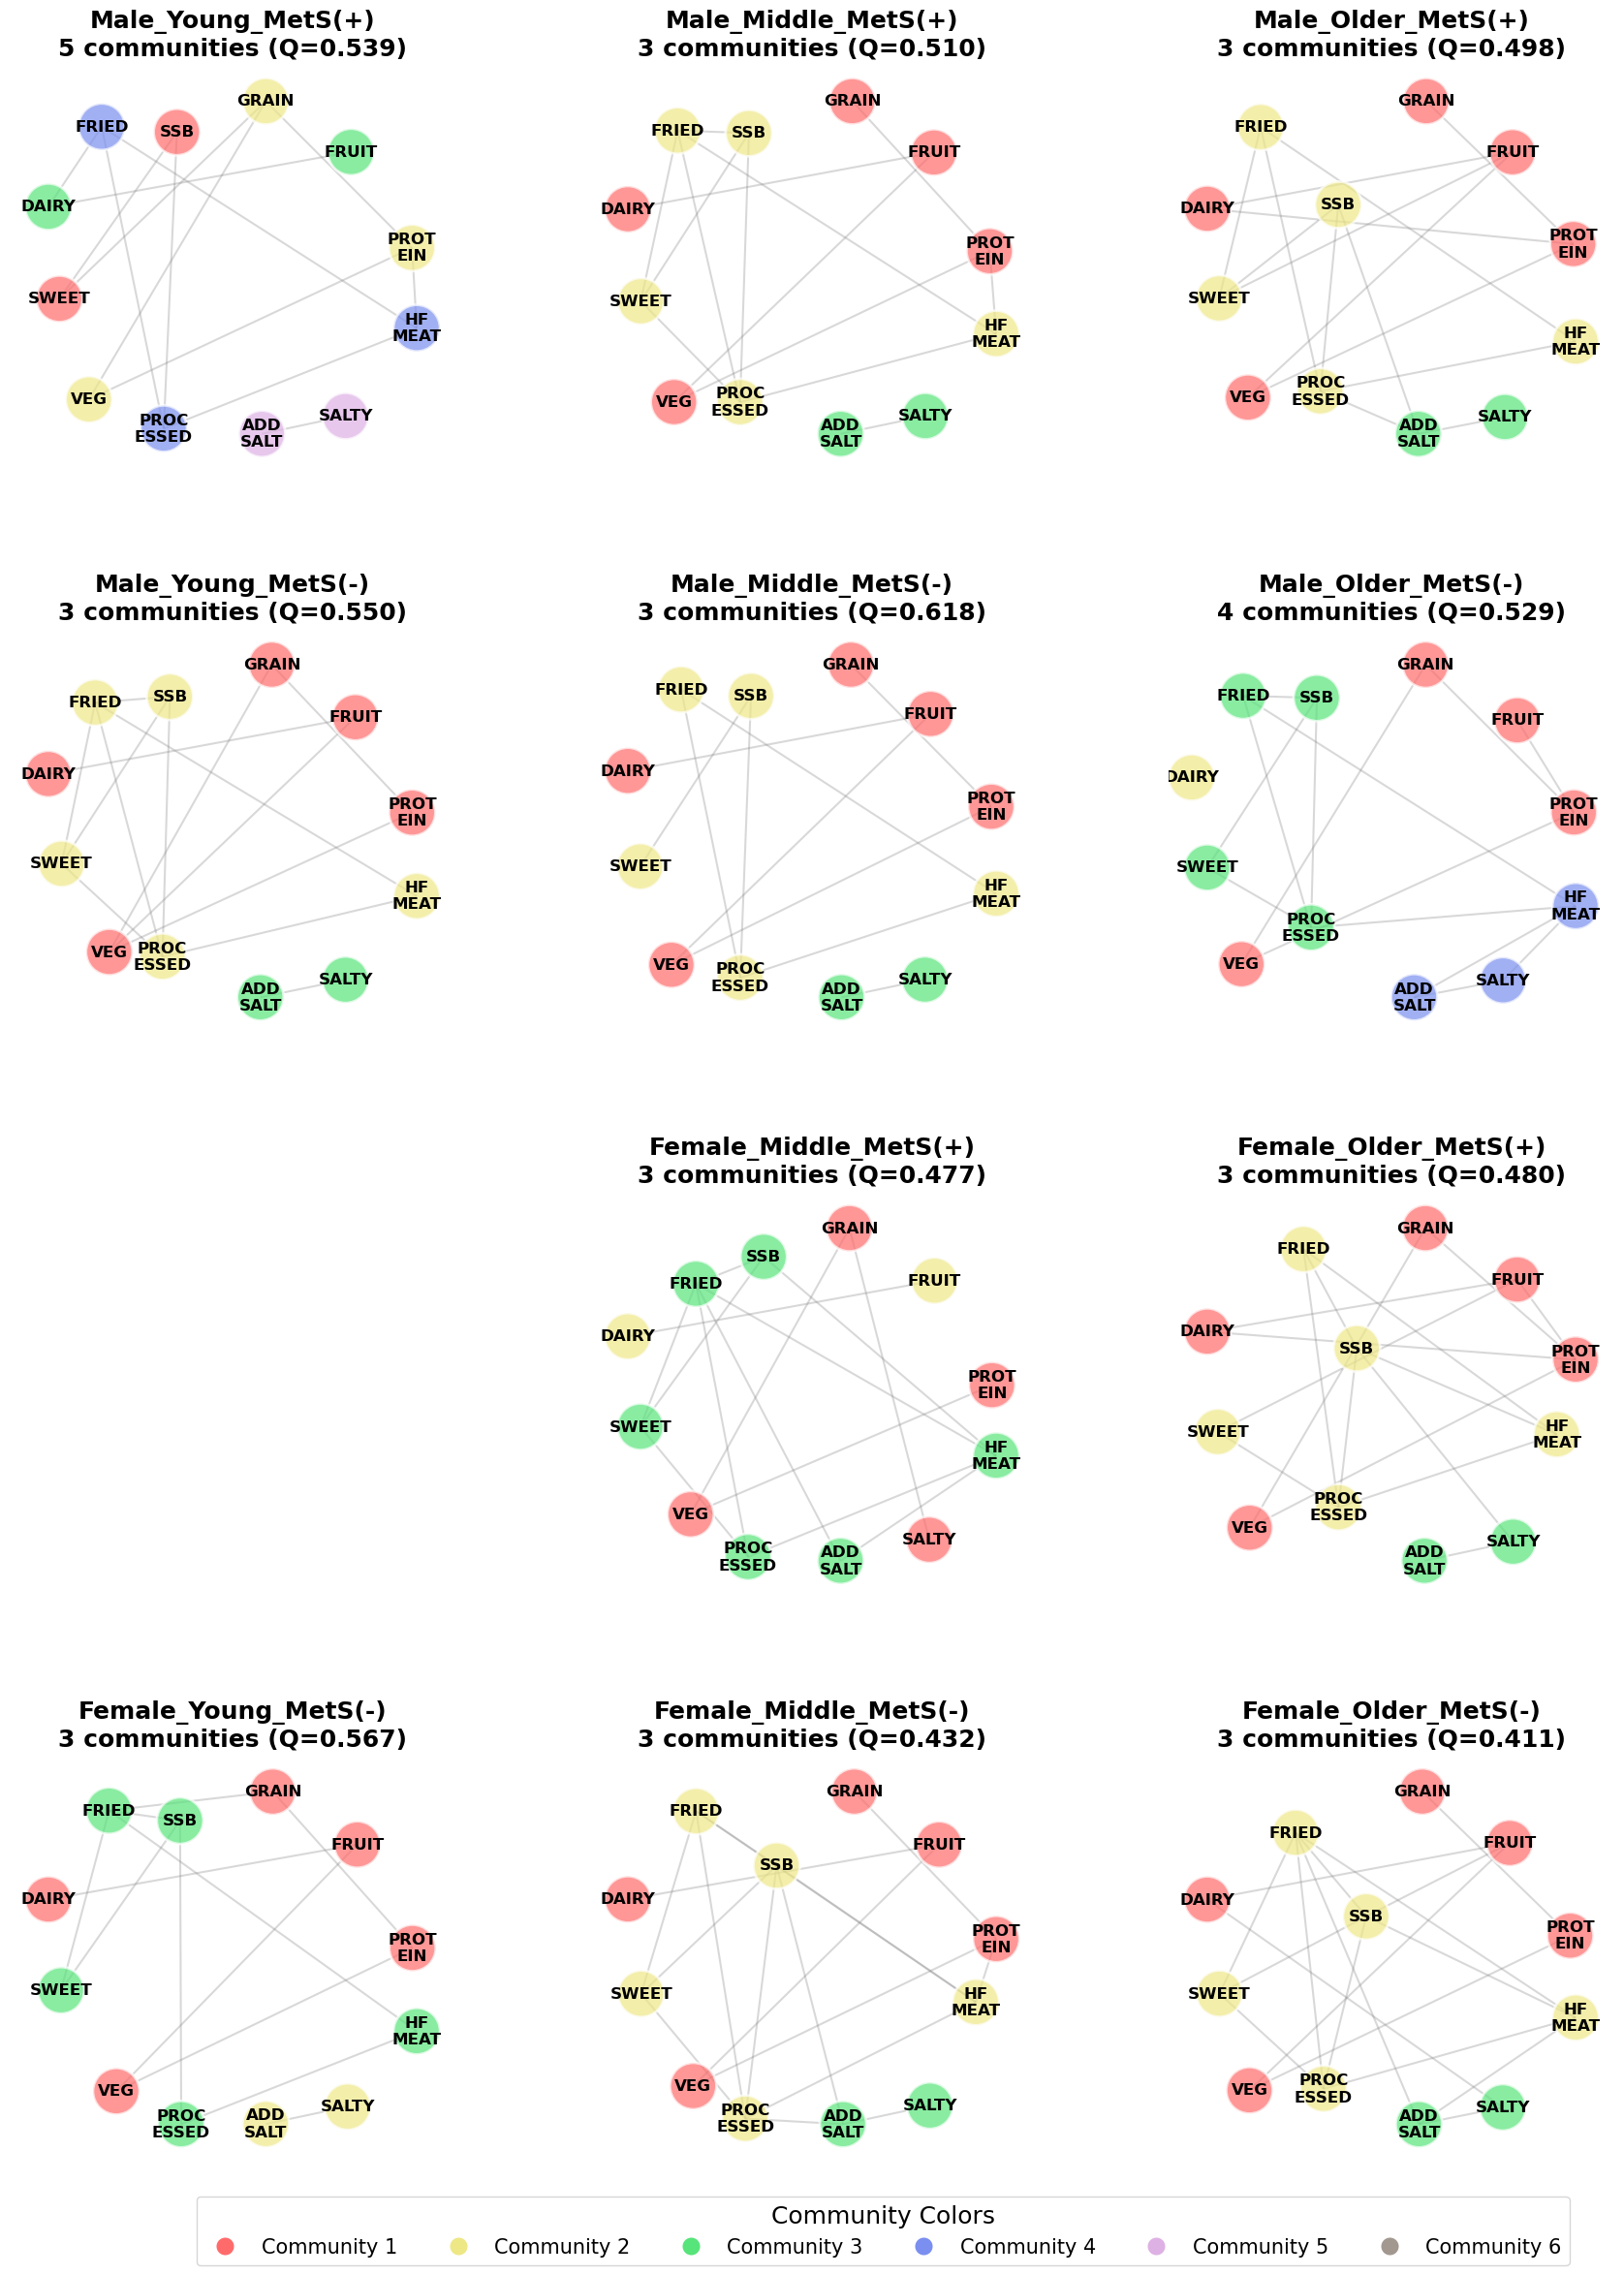

In [41]:
summary_df = load_statistics()
fig = plt.figure(figsize=(18, 24))
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3, left=0.05, right=0.97, top=0.95, bottom=0.05)

for idx, ((sex, age_group, mets_status), label) in enumerate(zip(GROUPS, GROUP_LABELS)):
    row = idx // 3
    col = idx % 3
    ax = fig.add_subplot(gs[row, col])
    
    group = f"{sex}_{age_group}_{mets_status}"    
    comm_file = NETWORK_DIR / f"ggm_network_{group}_communities.csv"
    G = load_network(sex, age_group, mets_status)

    if G is None or not comm_file.exists():
        ax.axis('off')
        continue
    
    comm_df = pd.read_csv(comm_file)
    
    node_colors = {}
    for _, row_data in comm_df.iterrows():
        comm_id = row_data['community_id']
        nodes = row_data['nodes'].split('; ')
        color = COMMUNITY_COLORS[(comm_id - 1) % len(COMMUNITY_COLORS)]
        for node in nodes:
            node_colors[node] = color
    
    colors = [node_colors.get(node, '#CCCCCC') for node in G.nodes()]
    pos = nx.spring_layout(G, seed=42, k=1.5, iterations=50)
    
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, width=1.5, edge_color='gray')
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1200, alpha=0.7, edgecolors='white', linewidths=2)
    
    labels_dict = {node: FOOD_ABBREV.get(node, node[:4]) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels_dict, ax=ax, font_size=12, font_weight='bold')
    
    n_comm = len(comm_df)
    mod_values = summary_df[summary_df['Group'] == group]['Modularity'].values
    modularity = mod_values[0] if len(mod_values) > 0 else 0.0

    ax.set_title(f"{label}\n{n_comm} communities (Q={modularity:.3f})", fontsize=18, fontweight='bold', pad=8)
    ax.axis('off')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=COMMUNITY_COLORS[i],
                markersize=15, label=f'Community {i+1}', 
                markeredgewidth=2, markeredgecolor='white')
    for i in range(6)
]
fig.legend(handles=legend_elements, loc='lower right', ncol=6,
            frameon=True, fontsize=15, bbox_to_anchor=(0.95, 0),
            title='Community Colors', title_fontsize=18)

output_file = FIGURES_DIR / 'Figure_S2_Community_Structure.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')

# 3.3. Mediating Role of Hub Foods on Dietary Patterns

## TABLE 1: Mediating Role of Hub Foods on Other Food Intakes

In [42]:
df_raw = load_raw_data()

ALL_FOODS = list(FOOD_ABBREV.keys())

def assign_tertile_group(data, food_col):
    p33, p67 = data[food_col].quantile([0.33, 0.67])
    
    if p33 == p67:
        median_val = data[food_col].median()
        return data[food_col].apply(lambda x: 'Low' if x <= median_val else 'High'), 'binary'
    
    def assign(x):
        return 'Low' if x <= p33 else ('Medium' if x <= p67 else 'High')
    tertiles = data[food_col].apply(assign)
    
    if len(tertiles.value_counts()) < 3:
        median_val = data[food_col].median()
        return data[food_col].apply(lambda x: 'Low' if x <= median_val else 'High'), 'binary'
    return tertiles, 'tertile'

all_results = []

for idx, (sex, age_group, status) in enumerate(GROUPS):
    
    G = load_network(sex, age_group, status)
    if G is None:
        continue

    degree_cent = nx.degree_centrality(G)
    top_hubs = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:3]

    mask = (df_raw['Sex'] == SEX_REVERSE[sex]) & \
           (df_raw['Age_Group'] == age_group) & \
           (df_raw['MetS_Status'] == status)
    group_data = df_raw[mask].copy()

    if len(group_data) < 30:
        continue

    for hub_food, hub_centrality in top_hubs:
        if hub_food not in group_data.columns or group_data[hub_food].nunique() < 2:
            continue

        try:
            group_data['Tertile'], split_method = assign_tertile_group(group_data, hub_food)
            low_data = group_data[group_data['Tertile'] == 'Low']
            high_data = group_data[group_data['Tertile'] == 'High']

            if len(low_data) < 10 or len(high_data) < 10:
                continue

            for food in ALL_FOODS:
                if food == hub_food or food not in group_data.columns:
                    continue

                low_mean = low_data[food].mean()
                low_std = low_data[food].std()
                high_mean = high_data[food].mean()
                high_std = high_data[food].std()

                stat, p_value = stats.mannwhitneyu(low_data[food], high_data[food], alternative='two-sided')

                all_results.append({
                    'Sex': SEX_REVERSE[sex],
                    'Age_Group': age_group,
                    'MetS_Status': status,
                    'Hub_Food': hub_food,
                    'Other_Food': food,
                    'N_Low': len(low_data),
                    'N_High': len(high_data),
                    'Low_Mean': low_mean,
                    'Low_SD': low_std,
                    'High_Mean': high_mean,
                    'High_SD': high_std,
                    'Difference': high_mean - low_mean,
                    'P_Value': p_value
                })

        except Exception as e:
            print(f"Error processing {sex}/{age_group}/{status} - {hub_food}: {e}")
            continue

df_results = pd.DataFrame(all_results)

df_results['Low_Intake'] = df_results.apply(
    lambda x: f"{x['Low_Mean']:.2f} ± {x['Low_SD']:.2f}", axis=1
)
df_results['High_Intake'] = df_results.apply(
    lambda x: f"{x['High_Mean']:.2f} ± {x['High_SD']:.2f}", axis=1
)
df_results['P_Value_Formatted'] = df_results['P_Value'].apply(
    lambda x: f"{x:.3f}" if x >= 0.001 else "<0.001"
)

df_results = df_results.sort_values(by=['Sex', 'Age_Group', 'MetS_Status', 'Hub_Food', 'P_Value'])
table1 = df_results[[
    'MetS_Status', 'Sex', 'Age_Group', 
    'Hub_Food', 'Other_Food', 'N_Low', 'N_High',
    'Low_Intake', 'High_Intake', 'Difference', 'P_Value_Formatted'
]].copy()

table1.columns = [
    'MetS Status', 'Sex', 'Age Group', 
    'Hub Food', 'Other Food', 'N (Low)', 'N (High)',
    'Low Intake (Mean ± SD)', 'High Intake (Mean ± SD)', 'Difference', 'P-value'
]

if os.path.exists(excel_file):
    with pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        table1.to_excel(writer, sheet_name='Table 1. Mediating Role of Hub Foods', index=False)
else:
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        table1.to_excel(writer, sheet_name='Table 1. Mediating Role of Hub Foods', index=False)

# 3.4. Association Between Hub Foods and Health Outcomes

## TABLE 2: Hub Foods and Health Indicators

In [43]:
def calculate_effect_size(low_group, high_group, indicator):
    n1, n2 = len(low_group), len(high_group)
    var1, var2 = low_group[indicator].var(), high_group[indicator].var()
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    mean_diff = high_group[indicator].mean() - low_group[indicator].mean()
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    return cohens_d

def perform_adjusted_analysis(group_data, hub_food, indicator):
    try:
        group_data['Tertile_Binary'] = (group_data['Tertile'] == 'High').astype(int)
        confounders = [c for c in ['Age'] if c in group_data.columns]
        
        if len(confounders) == 0:
            return None
        
        vars_to_include = ['Tertile_Binary'] + confounders
        analysis_data = group_data[vars_to_include + [indicator]].dropna()
        
        if len(analysis_data) < 30:
            return None
        
        X = add_constant(analysis_data[vars_to_include])
        y = analysis_data[indicator]
        model = OLS(y, X).fit()
        
        pval = model.pvalues['Tertile_Binary']
        
        return pval
    except:
        return None

def analyze_hub_health_association(mets_status, direction_labels):
    results = []

    for idx, (sex, age_group, status) in enumerate(GROUPS):
        if status != mets_status:
            continue

        G = load_network(sex, age_group, status)
        if G is None:
            continue

        top_hubs = sorted(nx.degree_centrality(G).items(), key=lambda x: x[1], reverse=True)[:3]
        group_data = df_raw[(df_raw['Sex'] == SEX_REVERSE[sex]) &
                           (df_raw['Age_Group'] == age_group) &
                           (df_raw['MetS_Status'] == status)].copy()

        if len(group_data) < 30:
            continue

        for hub_food, _ in top_hubs:
            if hub_food not in group_data.columns or group_data[hub_food].nunique() < 2:
                continue

            try:
                group_data['Tertile'], _ = assign_tertile_group(group_data, hub_food)
                low_group = group_data[group_data['Tertile'] == 'Low']
                high_group = group_data[group_data['Tertile'] == 'High']

                if len(low_group) < 10 or len(high_group) < 10:
                    continue

                for indicator in HEALTH_INDICATORS:
                    if indicator not in group_data.columns:
                        continue

                    low_mean = low_group[indicator].mean()
                    low_std = low_group[indicator].std()
                    high_mean = high_group[indicator].mean()
                    high_std = high_group[indicator].std()
                    diff = high_mean - low_mean
                    cohens_d = calculate_effect_size(low_group, high_group, indicator)
                    
                    p_value = perform_adjusted_analysis(group_data.copy(), hub_food, indicator)

                    results.append({
                        'MetS_Status': mets_status,
                        'Sex': SEX_REVERSE[sex],
                        'Age_Group': age_group,
                        'Hub_Food': hub_food,
                        'Health_Indicator': indicator,
                        'N_Low': len(low_group),
                        'N_High': len(high_group),
                        'Low_Mean': low_mean,
                        'Low_SD': low_std,
                        'High_Mean': high_mean,
                        'High_SD': high_std,
                        'Difference': diff,
                        'Cohens_d': cohens_d,
                        'P_Value': p_value
                    })
                    
            except Exception as e:
                print(f"Error: {GROUP_LABELS[idx]} - {hub_food}: {e}")

    df_results = pd.DataFrame(results)
    
    if len(df_results) == 0:
        return df_results
    
    valid_p = df_results['P_Value'].notna()
    if valid_p.sum() > 0:
        p_corrected = np.full(len(df_results), np.nan)
        _, corrected_vals, _, _ = multipletests(df_results.loc[valid_p, 'P_Value'], method='fdr_bh', alpha=0.1)
        p_corrected[valid_p] = corrected_vals
        df_results['P_Value_FDR'] = p_corrected
    else:
        df_results['P_Value_FDR'] = np.nan
    
    def assign_direction(row):
        if pd.isna(row['P_Value_FDR']) or row['P_Value_FDR'] >= 0.10 or abs(row['Cohens_d']) < 0.1:
            return 'No association'
        
        is_hdl = row['Health_Indicator'] == 'HDL-C (mg/dL)'
        diff = row['Difference']
        
        if is_hdl:
            return direction_labels[0] if diff > 0 else direction_labels[1]
        else:
            return direction_labels[1] if diff > 0 else direction_labels[0]
    
    df_results['Direction'] = df_results.apply(assign_direction, axis=1)
    
    return df_results

df_prevention = analyze_hub_health_association('MetS(-)', ['Protective', 'Risk'])
df_management = analyze_hub_health_association('MetS(+)', ['Alleviating', 'Aggravating'])
df_combined = pd.concat([df_prevention, df_management], ignore_index=True)

df_combined['Low_Intake'] = df_combined.apply(lambda x: f"{x['Low_Mean']:.2f} ± {x['Low_SD']:.2f}", axis=1)
df_combined['High_Intake'] = df_combined.apply(lambda x: f"{x['High_Mean']:.2f} ± {x['High_SD']:.2f}", axis=1)

def format_pvalue(p):
    if pd.isna(p):
        return 'N/A'
    elif p < 0.001:
        return '<0.001'
    else:
        return f"{p:.3f}"

df_combined['P_Final'] = df_combined['P_Value_FDR'].apply(format_pvalue)
df_combined['Effect_Size'] = df_combined['Cohens_d'].apply(lambda x: f"{x:.2f}")

df_combined = df_combined.sort_values(by=['MetS_Status', 'Sex', 'Age_Group', 'Hub_Food', 'P_Value_FDR'])

table2 = df_combined[[
    'MetS_Status', 'Sex', 'Age_Group', 'Hub_Food', 'Health_Indicator',
    'N_Low', 'N_High', 'Low_Intake', 'High_Intake',
    'Difference', 'Effect_Size', 'P_Final', 'Direction'
]].copy()

table2.columns = [
    'MetS Status', 'Sex', 'Age Group', 'Hub Food', 'Health Indicator',
    'N (Low)', 'N (High)', 'Low Tertile', 'High Tertile',
    'Difference', "Cohen's d", 'P-value', 'Association'
]

if os.path.exists(excel_file):
    with pd.ExcelWriter(excel_file, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        table2.to_excel(writer, sheet_name='Table 2. Hub Food and Health', index=False)
else:
    with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
        table2.to_excel(writer, sheet_name='Table 2. Hub Food and Health', index=False)

# 3.5. Integrated Dietary Strategy Based on Hub Foods

## FIGURE 2: Integrated Dietary Strategy Framework

In [44]:
def create_detailed_action_table(df_health, df_diet, top_n=3):
    def get_health_sign(row):
        indicator = row['Health Indicator'].lower()
        diff = row['Difference']
        is_hdl = 'hdl' in indicator
        
        if is_hdl:
            return '+' if diff > 0 else '-'
        else:
            return '+' if diff < 0 else '-'
    def summarize_action(signs):
        unique = set(signs)
        if unique == {'+'}: return '+'
        if unique == {'-'}: return '-'
        return '+/-'

    sig_h = df_health[df_health['Association'] != 'No association'].copy()
    sig_h['Health_Sign'] = sig_h.apply(get_health_sign, axis=1)
    action_df = sig_h.groupby(['MetS Status', 'Sex', 'Age Group', 'Hub Food'])['Health_Sign'].apply(summarize_action).reset_index(name='Action')
    
    def clean_p(val):
        if isinstance(val, str): val = val.replace('<', '').strip()
        return pd.to_numeric(val, errors='coerce')
    df_d = df_diet.copy()
    df_d['P_numeric'] = df_d['P-value'].apply(clean_p)
    sig_d = df_d[df_d['P_numeric'] < 0.05].copy()
    
    sig_d['Relation'] = sig_d['Difference'].apply(lambda x: '+' if x > 0 else '-')
    sig_d['Abs_Difference'] = sig_d['Difference'].abs()
    diet_detailed = sig_d.sort_values('Abs_Difference', ascending=False).groupby(
        ['MetS Status', 'Sex', 'Age Group', 'Hub Food']
    ).head(top_n)[['MetS Status', 'Sex', 'Age Group', 'Hub Food', 'Other Food', 'Relation']]

    final_df = pd.merge(action_df, diet_detailed, on=['MetS Status', 'Sex', 'Age Group', 'Hub Food'], how='left')
    
    final_df['Other Food'] = final_df['Other Food'].fillna('-')
    final_df['Relation'] = final_df['Relation'].fillna('')

    final_df = final_df.sort_values(by=['MetS Status', 'Sex', 'Age Group', 'Hub Food', 'Relation', 'Other Food'])
    
    final_df.columns = ['MetS Status', 'Sex', 'Age Group', 'Hub Food', 'Action (Health)', 'Co-consumed Food', 'Relation (Diet)']
    
    return final_df

df_final_detailed = create_detailed_action_table(table2, table1, top_n=3)

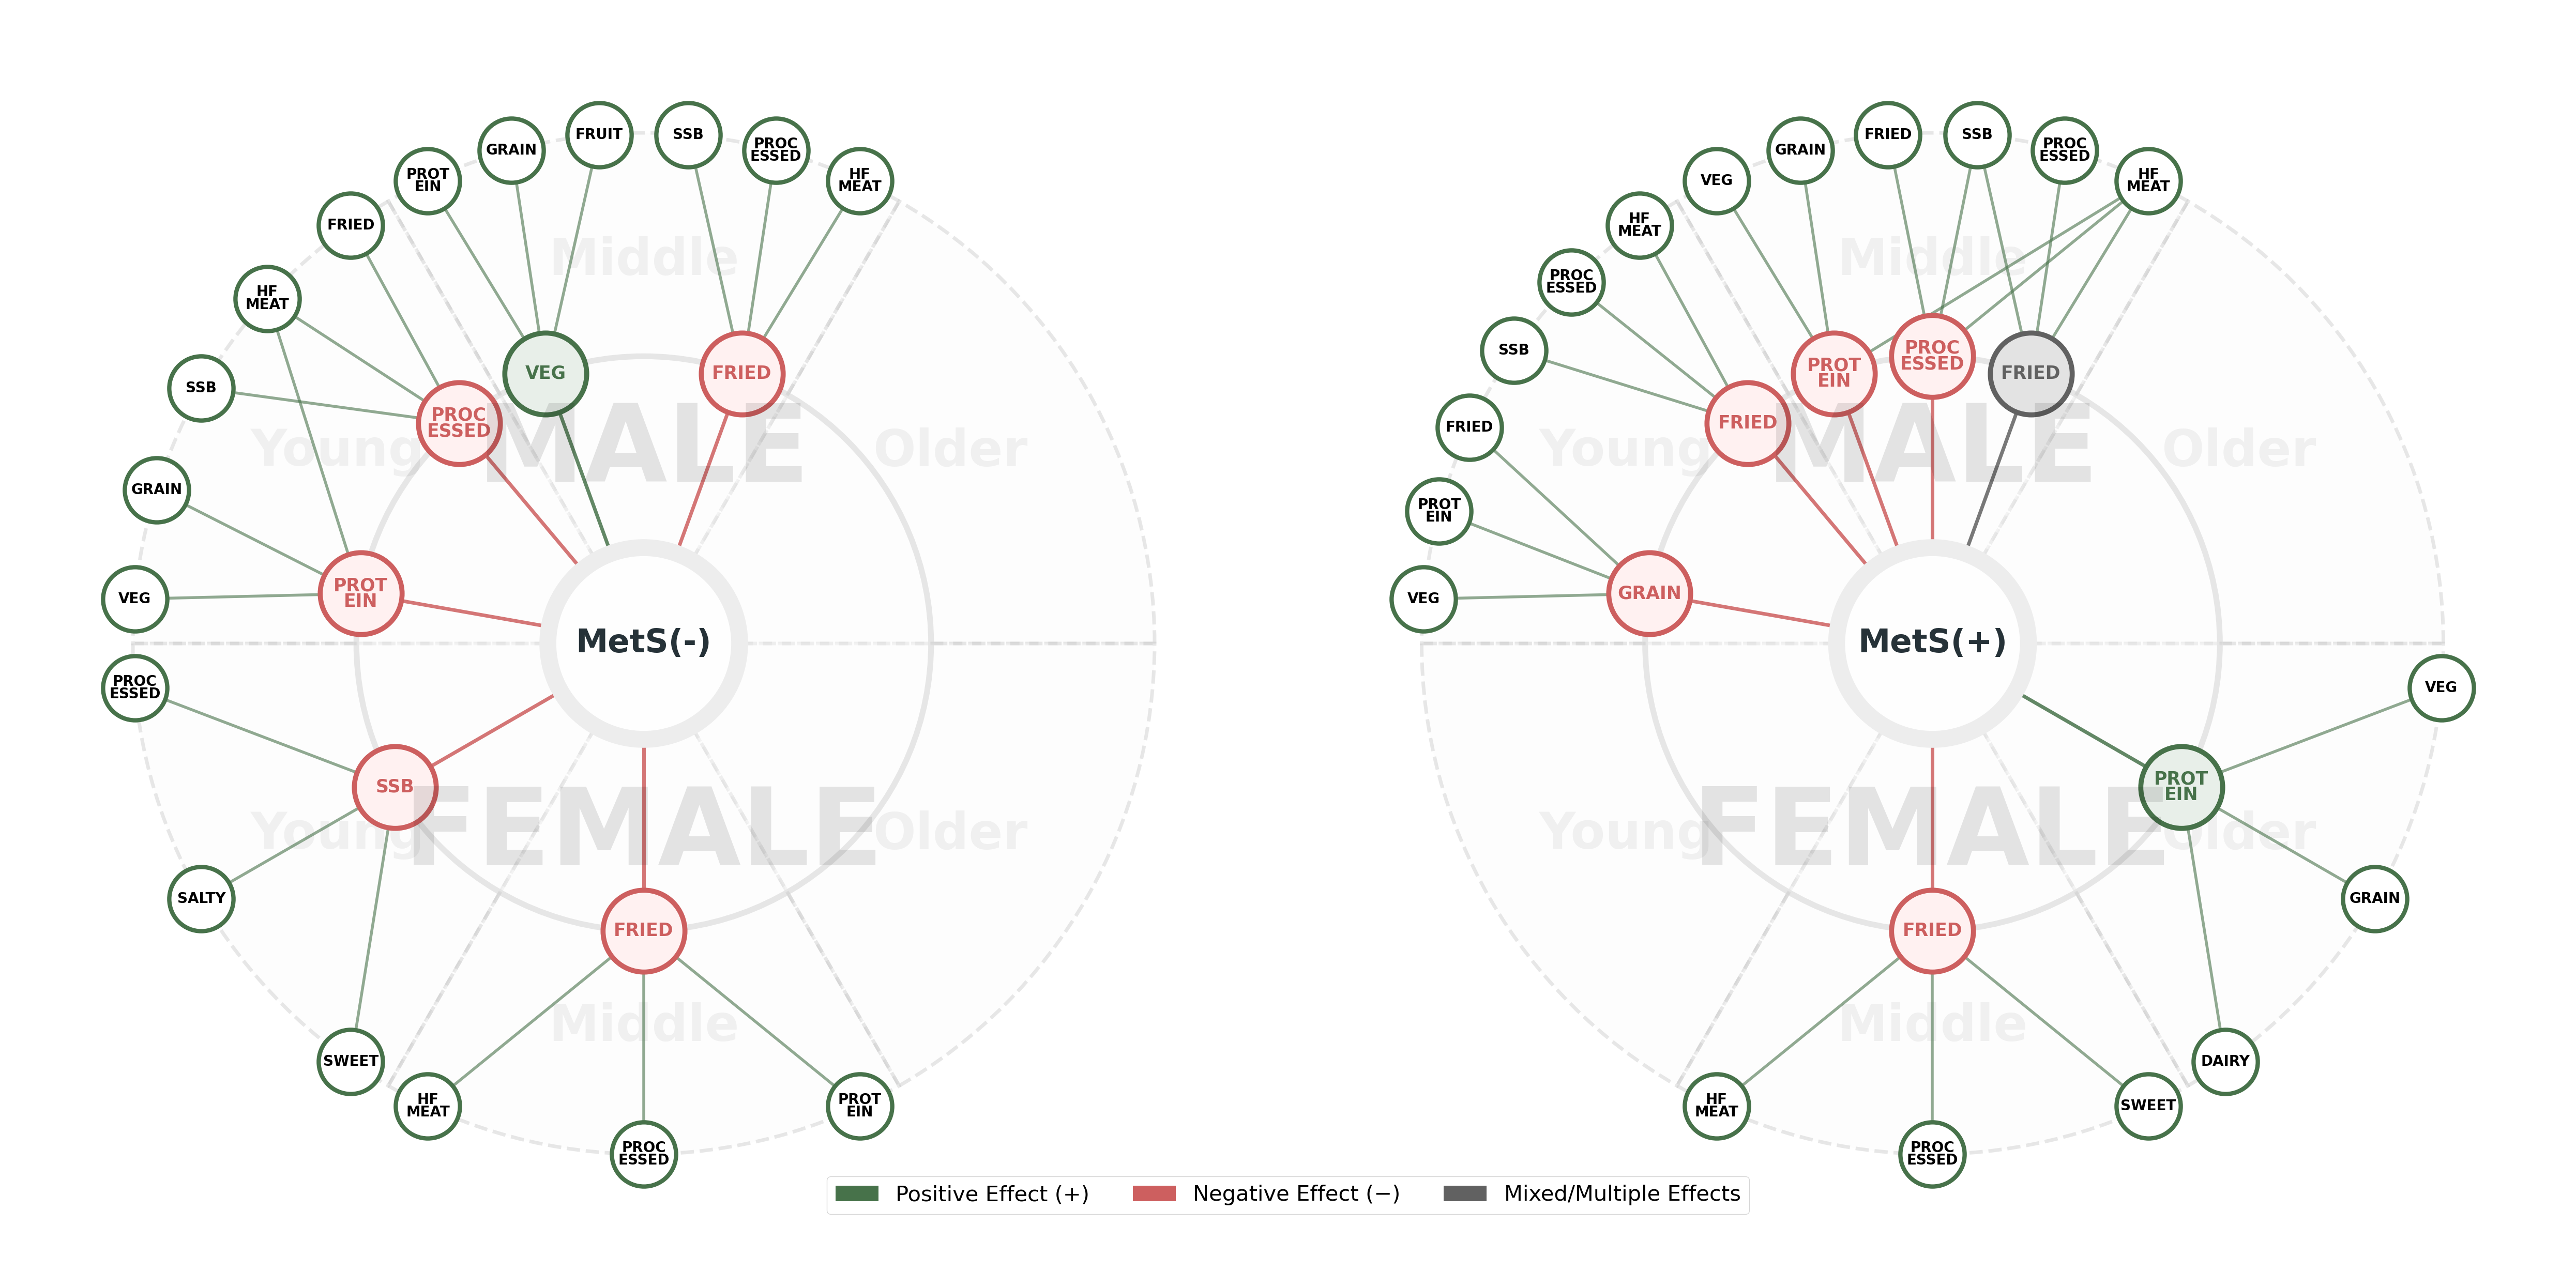

In [45]:
def draw_dual_circular_network(df):
    fig = plt.figure(figsize=(50, 25), facecolor='white')
    
    for idx, mets_target in enumerate(['MetS(-)', 'MetS(+)']):
        data = df[df['MetS Status'] == mets_target].copy()
        
        unique_ages = data['Age Group'].unique()
        age_map = {}
        for age in unique_ages:
            if '60' in age or '장년' in age: age_map[age] = 'Older'
            elif '40' in age or '중년' in age: age_map[age] = 'Middle'
            else: age_map[age] = 'Young'
        data['Age_Category'] = data['Age Group'].map(age_map)

        sectors = {
            ('M', 'Older'):  (0, 60),
            ('M', 'Middle'): (60, 120),
            ('M', 'Young'):  (120, 180),
            ('F', 'Young'):  (180, 240),
            ('F', 'Middle'): (240, 300),
            ('F', 'Older'):  (300, 360)
        }
        
        ax = fig.add_subplot(1, 2, idx + 1)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)

        color_map = {'+': "#47724A", '-': "#CD5F5F", '+/-': '#616161'}
        light_color_map = {'+': "#E8EFE9", '-': "#FFF1F1", '+/-': "#E3E3E3"}
        
        # 배경 원 및 섹터 구분선
        bg_circle = Circle((0, 0), 8, color='#F5F5F5', alpha=0.15, zorder=0, linewidth=0)
        ax.add_patch(bg_circle)
        for (sex, age_cat), (start_deg, end_deg) in sectors.items():
            wedge = Wedge((0, 0), 8, start_deg, end_deg, facecolor='white', edgecolor='#BDBDBD', linewidth=5, linestyle='--', alpha=0.35, zorder=1)
            ax.add_patch(wedge)
        md_wedge = Circle((0, 0), 4.5, facecolor='white', edgecolor='#BDBDBD', linewidth=8, alpha=0.35, zorder=1)
        ax.add_patch(md_wedge)

        # 성별 라벨
        gender_style = dict(ha='center', va='center', fontsize=150, fontweight='black', color='black', alpha=0.1, zorder=31, family='sans-serif')
        ax.text(0, 3, "MALE", **gender_style)
        ax.text(0, -3, "FEMALE", **gender_style)
        
        # 연령 라벨
        age_style = dict(ha='center', va='center', fontsize=70, fontweight='black', color='black', alpha=0.05)
        ax.text(-4.8, 3, "Young", **age_style)
        ax.text(0, 6, "Middle", **age_style)
        ax.text(4.8, 3, "Older", **age_style)
        ax.text(-4.8, -3, "Young", **age_style)
        ax.text(0, -6, "Middle", **age_style)
        ax.text(4.8, -3, "Older", **age_style)

        # 중심 원
        outer_circle = Circle((0, 0), 1.6, color="#EDEDED", lw=6, zorder=20, alpha=1)
        inner_circle = Circle((0, 0), 1.35, color='white', lw=3.5, zorder=21, alpha=0.95)
        ax.add_patch(outer_circle)
        ax.add_patch(inner_circle)
        ax.text(0, 0, mets_target, ha='center', va='center', fontsize=45, fontweight='bold', color='#263238', zorder=22, family='sans-serif')
        
        # 메인 그림
        for sex in ['M', 'F']:
            for age_cat in ['Older', 'Middle', 'Young']:
                group_data = data[(data['Sex'] == sex) & (data['Age_Category'] == age_cat)]
                if group_data.empty: 
                    continue
                
                start_deg, end_deg = sectors.get((sex, age_cat), (0, 0))
                hubs = group_data['Hub Food'].unique()
                if len(hubs) == 1:
                    hub_angles = [(start_deg + end_deg) / 2]
                else:
                    hub_angles = np.linspace(start_deg + 10, end_deg - 10, len(hubs))
                
                hub_positions = {}
                
                for i, hub in enumerate(hubs):
                    hub_angle_deg = hub_angles[i]
                    hub_angle_rad = np.radians(hub_angle_deg)
                    
                    hx = 4.5 * np.cos(hub_angle_rad)
                    hy = 4.5 * np.sin(hub_angle_rad)
                    
                    hub_positions[hub] = (hx, hy, hub_angle_deg)
                    
                    hub_info = group_data[group_data['Hub Food'] == hub].iloc[0]
                    hub_action = hub_info['Action (Health)']
                    light_hub_color = light_color_map.get(hub_action, 'gray')
                    hub_color = color_map.get(hub_action, 'gray')

                    ax.plot([0, hx], [0, hy], color=hub_color, lw=5, alpha=0.85, zorder=4, solid_capstyle='round')
                    ax.scatter(hx, hy, color=light_hub_color, s=13000, zorder=10, edgecolors=hub_color, linewidth=7, alpha=1)
                    
                    hub_abbrev = FOOD_ABBREV.get(hub, hub)
                    ax.text(hx, hy, hub_abbrev, ha='center', va='center', fontsize=25, fontweight='bold', 
                           color=hub_color, zorder=11, linespacing=0.88, family='sans-serif')
                
                food_connections = defaultdict(list)
                for hub in hubs:
                    sub_data = group_data[group_data['Hub Food'] == hub]
                    foods = sub_data['Co-consumed Food'].unique()
                    foods = [f for f in foods if f != '-']
                    
                    for food in foods:
                        relation = sub_data[sub_data['Co-consumed Food'] == food]['Relation (Diet)'].values[0]
                        food_connections[food].append((hub, relation))
                
                unique_foods = list(food_connections.keys())
                if len(unique_foods) == 0:
                    continue
                
                if len(unique_foods) == 1:
                    food_angles = [(start_deg + end_deg) / 2]
                else:
                    food_angles = np.linspace(start_deg + 5, end_deg - 5, len(unique_foods))
                
                for j, food in enumerate(unique_foods):
                    f_angle_deg = food_angles[j]
                    f_angle_rad = np.radians(f_angle_deg)
                    
                    fx = 8 * np.cos(f_angle_rad)
                    fy = 8 * np.sin(f_angle_rad)
                    
                    connected_hubs = food_connections[food]
                    for hub_name, relation in connected_hubs:
                        hx, hy, _ = hub_positions[hub_name]
                        line_color = color_map.get(relation, 'gray')
                        ax.plot([hx, fx], [hy, fy], color=line_color, lw=4, alpha=0.6, zorder=6, solid_capstyle='round')
                    
                    relations = [rel for _, rel in connected_hubs]
                    if len(set(relations)) > 1:
                        node_color = color_map['+/-']
                    else:
                        node_color = color_map[relations[0]]
                    
                    ax.scatter(fx, fy, color='white', s=8000, zorder=9, edgecolors=node_color, linewidth=6, alpha=1)
                    
                    ax.text(fx, fy, FOOD_ABBREV.get(food, food), ha='center', va='center', fontsize=20, fontweight='bold', 
                           color='black', zorder=10, linespacing=0.82, family='sans-serif')

        # 범례
        if idx == 1:
            legend_elements = [
                mpatches.Patch(facecolor=color_map['+'], label='Positive Effect (+)', edgecolor='none'),
                mpatches.Patch(facecolor=color_map['-'], label='Negative Effect (−)', edgecolor='none'),
                mpatches.Patch(facecolor=color_map['+/-'], label='Mixed/Multiple Effects', edgecolor='none'),
            ]
            legend = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.05), 
                            fontsize=30, ncol=3, frameon=True, fancybox=True)
            plt.setp(legend.get_title(), fontweight='bold')

    plt.tight_layout()
    output_file = FIGURES_DIR / 'Figure_2_Final_Comment.png'
    plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='none', transparent=True)
    plt.show()

draw_dual_circular_network(df_final_detailed)

# ETC

In [46]:
'''# Color scheme
RISK_COLOR = '#E74C3C'          # Red for Risk Hubs (REDUCE)
PROTECTIVE_COLOR = '#27AE60'    # Green for Protective Hubs (PROMOTE)
SHARED_COLOR = '#95A5A6'        # Gray for Shared Hubs
OTHER_COLOR = '#ECF0F1'         # Light gray for other foods
EDGE_COLOR = '#BDC3C7'          # Gray for edges

# Food abbreviations
FOOD_ABBREV = {
    'Grain Products': 'Grain',
    'Protein Foods': 'Protein',
    'Vegetables': 'Veg',
    'Dairy Products': 'Dairy',
    'Fruits': 'Fruit',
    'Fried Foods': 'Fried',
    'High Fat Meat': 'HFMeat',
    'Processed Foods': 'Processed',
    'Sugar-Sweetened Beverages': 'SSB',
    'Additional Salt Use': 'AddSalt',
    'Salty Food Consumption': 'Salty',
    'Sweet Food Consumption': 'Sweet'
}

def parse_hub_list(hub_string):
    if pd.isna(hub_string) or hub_string == 'None' or hub_string == 'N/A':
        return []
    return [h.strip() for h in str(hub_string).split(',')]

def get_node_color(node, risk_hubs, protective_hubs, shared_hubs):
    if node in risk_hubs:
        return RISK_COLOR
    elif node in protective_hubs:
        return PROTECTIVE_COLOR
    elif node in shared_hubs:
        return SHARED_COLOR
    else:
        return OTHER_COLOR

def draw_network_subplot(ax, G, pos, risk_hubs, protective_hubs, shared_hubs, hub_degrees, title, metrics_color):
    node_colors = [get_node_color(node, risk_hubs, protective_hubs, shared_hubs) for node in G.nodes()]
    hub_nodes = set(risk_hubs + protective_hubs + shared_hubs)
    node_sizes = []
    for node in G.nodes():
        degree = G.degree(node)
        node_sizes.append(degree * 80 + 200)
    
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.2, width=1.5, edge_color=EDGE_COLOR)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, 
                           alpha=0.85, edgecolors='white', linewidths=1.5)
    
    labels = {node: FOOD_ABBREV.get(node, node[:8]) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7, font_weight='normal')
    
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, color=metrics_color)
    ax.axis('off')

# Load data
table_s3 = pd.read_csv(TABLES_DIR / 'Table_S3_Personalized_Coaching_Strategies.csv')
network_summary = pd.read_csv(NETWORK_DIR / 'ggm_network_summary.csv')
groups_to_plot = [
    ('남성', '청년층(19-39세)', 'Male', 'Young (19-39y)', 'Male_Young'),
    ('남성', '중년층(40-59세)', 'Male', 'Middle-aged (40-59y)', 'Male_Middle'),
    ('남성', '장년층(60-74세)', 'Male', 'Older (60-74y)', 'Male_Older'),
    ('여성', '중년층(40-59세)', 'Female', 'Middle-aged (40-59y)', 'Female_Middle'),
    ('여성', '장년층(60-74세)', 'Female', 'Older (60-74y)', 'Female_Older'),
]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
plt.subplots_adjust(left=0.05, right=0.95, top=0.98, bottom=0.02, hspace=0.3, wspace=0.15)

for row, (sex_kr, age_kr, sex_en, age_en, label) in enumerate(groups_to_plot):
    s3_row = table_s3[(table_s3['Sex'] == sex_en) & (table_s3['Age_Group'] == age_en)].iloc[0]
    
    risk_hubs = parse_hub_list(s3_row['Risk_Hubs_in_MetS'])
    protective_hubs = parse_hub_list(s3_row['Protective_Hubs_in_Healthy'])
    shared_hubs = parse_hub_list(s3_row['Shared_Hubs'])
    
    G_plus = load_network(sex_kr, age_kr, 'MetS(+)')
    G_minus = load_network(sex_kr, age_kr, 'MetS(-)')
    
    # Get network statistics
    group_plus = f"{sex_kr}_{age_kr}_MetS(+)"
    group_minus = f"{sex_kr}_{age_kr}_MetS(-)"
    
    plus_row = network_summary[network_summary['Group'] == group_plus].iloc[0]
    minus_row = network_summary[network_summary['Group'] == group_minus].iloc[0]
    
    # Hub degrees (for node sizing)
    hub_degrees_plus = {
        plus_row['Hub_1_Name']: plus_row['Hub_1_Degree'],
        plus_row['Hub_2_Name']: plus_row['Hub_2_Degree'],
        plus_row['Hub_3_Name']: plus_row['Hub_3_Degree'],
    }
    
    hub_degrees_minus = {
        minus_row['Hub_1_Name']: minus_row['Hub_1_Degree'],
        minus_row['Hub_2_Name']: minus_row['Hub_2_Degree'],
        minus_row['Hub_3_Name']: minus_row['Hub_3_Degree'],
    }
    
    # Create consistent layout using combined graph
    all_nodes = list(set(list(G_plus.nodes()) + list(G_minus.nodes())))
    G_combined = nx.Graph()
    G_combined.add_nodes_from(all_nodes)
    G_combined.add_edges_from(G_plus.edges())
    G_combined.add_edges_from(G_minus.edges())
    pos = nx.spring_layout(G_combined, seed=42, k=2.5, iterations=100)
    
    # Draw MetS(+) network (left column)
    draw_network_subplot(
        axes[row, 0], G_plus, pos, risk_hubs, [], shared_hubs, 
        hub_degrees_plus, f'{label} MetS(+)', RISK_COLOR
    )
    
    # Draw MetS(-) network (right column)
    draw_network_subplot(
        axes[row, 1], G_minus, pos, [], protective_hubs, shared_hubs, 
        hub_degrees_minus, f'{label} MetS(-)', PROTECTIVE_COLOR
    )

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=RISK_COLOR, edgecolor='white', label='Risk Hubs (MetS+)'),
    Patch(facecolor=PROTECTIVE_COLOR, edgecolor='white', label='Protective Hubs (Healthy)'),
    Patch(facecolor=SHARED_COLOR, edgecolor='white', label='Shared Hubs'),
    Patch(facecolor=OTHER_COLOR, edgecolor='white', label='Other Foods')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
            frameon=True, fontsize=11, bbox_to_anchor=(0.5, -0.01))

# Save figure
output_path = FIGURES_DIR / 'Figure_3_Individual_Networks_Grid.png'
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')'''

'# Color scheme\nRISK_COLOR = \'#E74C3C\'          # Red for Risk Hubs (REDUCE)\nPROTECTIVE_COLOR = \'#27AE60\'    # Green for Protective Hubs (PROMOTE)\nSHARED_COLOR = \'#95A5A6\'        # Gray for Shared Hubs\nOTHER_COLOR = \'#ECF0F1\'         # Light gray for other foods\nEDGE_COLOR = \'#BDC3C7\'          # Gray for edges\n\n# Food abbreviations\nFOOD_ABBREV = {\n    \'Grain Products\': \'Grain\',\n    \'Protein Foods\': \'Protein\',\n    \'Vegetables\': \'Veg\',\n    \'Dairy Products\': \'Dairy\',\n    \'Fruits\': \'Fruit\',\n    \'Fried Foods\': \'Fried\',\n    \'High Fat Meat\': \'HFMeat\',\n    \'Processed Foods\': \'Processed\',\n    \'Sugar-Sweetened Beverages\': \'SSB\',\n    \'Additional Salt Use\': \'AddSalt\',\n    \'Salty Food Consumption\': \'Salty\',\n    \'Sweet Food Consumption\': \'Sweet\'\n}\n\ndef parse_hub_list(hub_string):\n    if pd.isna(hub_string) or hub_string == \'None\' or hub_string == \'N/A\':\n        return []\n    return [h.strip() for h in str(hub_str

In [47]:
'''def prepare_mets_differences(network_df):
    groups = [
        ('Male', 'Young\n(19-39y)', '남성_청년층(19-39세)'),
        ('Male', 'Middle-aged\n(40-59y)', '남성_중년층(40-59세)'),
        ('Male', 'Older\n(60-74y)', '남성_장년층(60-74세)'),
        ('Female', 'Young\n(19-39y)', '여성_청년층(19-39세)'),
        ('Female', 'Middle-aged\n(40-59y)', '여성_중년층(40-59세)'),
        ('Female', 'Older\n(60-74y)', '여성_장년층(60-74세)'),
    ]
    
    results = []
    for sex, age_label, group_prefix in groups:
        mets_plus = network_df[network_df['Group'] == f"{group_prefix}_MetS(+)"]
        mets_minus = network_df[network_df['Group'] == f"{group_prefix}_MetS(-)"]
        
        if len(mets_plus) == 0 or len(mets_minus) == 0:
            results.append({
                'Sex': sex,
                'Age': age_label,
                'Delta_Edges': np.nan,
                'Delta_Density': np.nan,
                'Delta_Modularity': np.nan,
                'Delta_Communities': np.nan,
                'N_Plus': 0,
                'N_Minus': mets_minus.iloc[0]['N_Samples'] if len(mets_minus) > 0 else 0
            })
        else:
            plus = mets_plus.iloc[0]
            minus = mets_minus.iloc[0]
            
            results.append({
                'Sex': sex,
                'Age': age_label,
                'Delta_Edges': plus['N_Edges'] - minus['N_Edges'],
                'Delta_Density': plus['Density'] - minus['Density'],
                'Delta_Modularity': plus['Modularity'] - minus['Modularity'],
                'Delta_Communities': plus['N_Communities'] - minus['N_Communities'],
                'N_Plus': plus['N_Samples'],
                'N_Minus': minus['N_Samples']
            })
    
    return pd.DataFrame(results)

def plot_panel_a_metrics_heatmap(ax, diff_df):
    diff_df_valid = diff_df.dropna(subset=['Delta_Edges'])
    diff_df_valid['Group'] = diff_df_valid['Sex'] + '\n' + diff_df_valid['Age']
    
    metrics = ['Delta_Edges', 'Delta_Density', 'Delta_Modularity']
    metric_labels = ['Δ Edges\n(connectivity)', 'Δ Density\n(network density)', 'Δ Modularity\n(segmentation)']
    
    # Create matrix
    matrix = diff_df_valid[metrics].values
    im = ax.imshow(matrix.T, cmap='RdBu_r', aspect='auto', vmin=-0.15, vmax=0.15)
    
    # Set ticks
    ax.set_xticks(range(len(diff_df_valid)))
    ax.set_xticklabels(diff_df_valid['Group'], rotation=0, ha='center', fontsize=10)
    ax.set_yticks(range(len(metrics)))
    ax.set_yticklabels(metric_labels, fontsize=11)
    
    # Add values as text
    for i in range(len(metrics)):
        for j in range(len(diff_df_valid)):
            value = matrix[j, i]
            if not np.isnan(value):
                text_color = 'white' if abs(value) > 0.08 else 'black'
                text = f'{value:+.2f}' if i < 2 else f'{value:+.3f}'
                ax.text(j, i, text,
                       ha='center', va='center', color=text_color, 
                       fontsize=10, weight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.15, aspect=30)
    cbar.set_label('MetS(+) - MetS(-)', fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    
    ax.set_title('A. Network Structure Changes in Metabolic Syndrome', 
                fontweight='bold', fontsize=13, pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

def plot_panel_b_network_complexity(ax, network_df):
    mets_plus = network_df[network_df['MetS_Status'] == 'MetS(+)']
    mets_minus = network_df[network_df['MetS_Status'] == 'MetS(-)']
    
    # Plot scatter
    scatter1 = ax.scatter(mets_plus['N_Edges'], mets_plus['Modularity'], 
                         s=mets_plus['N_Samples']/30, c='#E74C3C', alpha=0.7, 
                         edgecolors='black', linewidths=1.5, label='MetS(+)', marker='o')
    scatter2 = ax.scatter(mets_minus['N_Edges'], mets_minus['Modularity'], 
                         s=mets_minus['N_Samples']/30, c='#3498DB', alpha=0.7, 
                         edgecolors='black', linewidths=1.5, label='MetS(-)', marker='s')
    
    male_middle_plus = network_df[network_df['Group'] == '남성_중년층(40-59세)_MetS(+)'].iloc[0]
    male_middle_minus = network_df[network_df['Group'] == '남성_중년층(40-59세)_MetS(-)'].iloc[0]
    
    ax.annotate('Male 40-59y\nMetS(+)', 
                xy=(male_middle_plus['N_Edges'], male_middle_plus['Modularity']),
                xytext=(5, -15), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#E74C3C', 
                         alpha=0.3, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))
    
    ax.annotate('Male 40-59y\nMetS(-)', 
                xy=(male_middle_minus['N_Edges'], male_middle_minus['Modularity']),
                xytext=(5, 10), textcoords='offset points', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#3498DB', 
                         alpha=0.3, edgecolor='black', linewidth=1),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1))
    
    # Axes labels
    ax.set_xlabel('Number of Edges (Network Connectivity)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Modularity Q (Dietary Pattern Segmentation)', fontsize=11, fontweight='bold')
    ax.set_xlim(8.5, 14.5)
    ax.set_ylim(0.45, 0.63)
    
    # Add legend for MetS status
    legend1 = ax.legend(loc='lower left', frameon=True, fancybox=False, 
                       fontsize=10, title='MetS Status', title_fontsize=11)
    
    # Add size legend
    sizes = [500, 2000, 5000]
    size_labels = ['500', '2,000', '5,000']
    legend_elements = [plt.scatter([], [], s=s/30, c='gray', alpha=0.5, 
                                  edgecolors='black', linewidths=1.5) 
                      for s in sizes]
    legend2 = ax.legend(legend_elements, size_labels, title='Sample Size', 
                       loc='upper right', frameon=True, fancybox=False, 
                       fontsize=9, title_fontsize=10)
    ax.add_artist(legend1)
    
    ax.set_title('B. Network Complexity by MetS Status', 
                fontweight='bold', fontsize=13, pad=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.5)

network_df = pd.read_csv('../result/networks/ggm_network_summary.csv')
diff_df = prepare_mets_differences(network_df)

fig = plt.figure(figsize=(18, 7))
gs = GridSpec(1, 2, figure=fig, hspace=0.30, wspace=0.35, left=0.06, right=0.96, top=0.90, bottom=0.10)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])

plot_panel_a_metrics_heatmap(ax_a, diff_df)
plot_panel_b_network_complexity(ax_b, network_df)

output_file = FIGURES_DIR / 'Supplementary_Figure_3_MetS_Network_Effects.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')'''

'def prepare_mets_differences(network_df):\n    groups = [\n        (\'Male\', \'Young\n(19-39y)\', \'남성_청년층(19-39세)\'),\n        (\'Male\', \'Middle-aged\n(40-59y)\', \'남성_중년층(40-59세)\'),\n        (\'Male\', \'Older\n(60-74y)\', \'남성_장년층(60-74세)\'),\n        (\'Female\', \'Young\n(19-39y)\', \'여성_청년층(19-39세)\'),\n        (\'Female\', \'Middle-aged\n(40-59y)\', \'여성_중년층(40-59세)\'),\n        (\'Female\', \'Older\n(60-74y)\', \'여성_장년층(60-74세)\'),\n    ]\n    \n    results = []\n    for sex, age_label, group_prefix in groups:\n        mets_plus = network_df[network_df[\'Group\'] == f"{group_prefix}_MetS(+)"]\n        mets_minus = network_df[network_df[\'Group\'] == f"{group_prefix}_MetS(-)"]\n        \n        if len(mets_plus) == 0 or len(mets_minus) == 0:\n            results.append({\n                \'Sex\': sex,\n                \'Age\': age_label,\n                \'Delta_Edges\': np.nan,\n                \'Delta_Density\': np.nan,\n                \'Delta_Modularity\': np.nan,\n   

In [48]:
'''fig, axes = plt.subplots(4, 3, figsize=(18, 24), sharex=True, sharey=True)
axes = axes.flatten()

for idx, (sex, age_group, mets_status) in enumerate(GROUPS):
    ax = axes[idx]
    
    partial_corr_df = load_partial_corr_matrix(sex, age_group, mets_status)
    
    show_cbar = (idx == 12)
    
    sns.heatmap(
        partial_corr_df,
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        cbar=show_cbar,
        cbar_kws={'label': 'Partial Correlation'} if show_cbar else None,
        ax=ax,
        vmin=-1,
        vmax=1,
        square=True
    )
    
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for idx in range(9, 12):
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=8)
for idx in [0, 3, 6, 9]:
    axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0, fontsize=8)

# Hide unused subplots
for idx in range(len(GROUPS), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
output_file = FIGURES_DIR / 'Supplementary_Figure_1_Partial_Correlation_Heatmaps_GGM.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor='white')'''

"fig, axes = plt.subplots(4, 3, figsize=(18, 24), sharex=True, sharey=True)\naxes = axes.flatten()\n\nfor idx, (sex, age_group, mets_status) in enumerate(GROUPS):\n    ax = axes[idx]\n    \n    partial_corr_df = load_partial_corr_matrix(sex, age_group, mets_status)\n    \n    show_cbar = (idx == 12)\n    \n    sns.heatmap(\n        partial_corr_df,\n        cmap='RdBu_r',\n        center=0,\n        annot=True,\n        fmt='.2f',\n        linewidths=0.5,\n        cbar=show_cbar,\n        cbar_kws={'label': 'Partial Correlation'} if show_cbar else None,\n        ax=ax,\n        vmin=-1,\n        vmax=1,\n        square=True\n    )\n    \n    ax.set_title(label, fontsize=12, fontweight='bold')\n    ax.set_xlabel('')\n    ax.set_ylabel('')\n\nfor idx in range(9, 12):\n    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right', fontsize=8)\nfor idx in [0, 3, 6, 9]:\n    axes[idx].set_yticklabels(axes[idx].get_yticklabels(), rotation=0, fontsize=8)\n\n# Hide unused 